In [1]:
import pandas as pd
data = pd.read_csv(r"C:\Users\aruna\Downloads\creditcard.csv\creditcard.csv")

In [2]:
from sklearn.model_selection import train_test_split

X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(score_func=mutual_info_classif, k=6)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)


selected_features = X_train.columns[selector.get_support()]
print("Selected features:", selected_features)

X_train = X_train[selected_features]
X_test = X_test[selected_features]

Selected features: Index(['V10', 'V11', 'V12', 'V14', 'V16', 'V17'], dtype='object')


In [4]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=selected_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=selected_features,
    index=X_test.index
)

In [18]:
import sys
!{sys.executable} -m pip install "protobuf>=3.20,<7" --force-reinstall
!{sys.executable} -m pip install tensorflow

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1


  You can safely remove it manually.


In [19]:
import numpy as np
import tensorflow as tf
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import StratifiedKFold
from sklearn import metrics

from bayes_opt import BayesianOptimization

In [25]:
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.models import Sequential

def generate_model(neuronPct):
    
    input_dim = X_train_scaled.shape[1]
    
    # 🔥 critical fix
    neurons = max(4, int(input_dim * neuronPct))
    
    model = Sequential([
        Input(shape=(input_dim,)),
        
        Dense(neurons, activation='relu'),
        Dropout(0.3),
        Dense(max(2, neurons // 2), activation='relu'),
        Dense(max(1, neurons // 4), activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    return model

In [26]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

Class weights: {np.int64(0): np.float64(0.5008661206149896), np.int64(1): np.float64(289.14340101522845)}


In [27]:
def keras_cv(batch_size, epochs, neuronPct):
    tf.keras.backend.clear_session()
    batch_size = int(batch_size)
    epochs = int(epochs)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = []

    for train, test in cv.split(X_train_scaled, y_train):

        x_train = X_train_scaled.iloc[train]
        y_tr = y_train.iloc[train]

        x_test = X_train_scaled.iloc[test]
        y_te = y_train.iloc[test]

        model = generate_model(neuronPct)

        model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
        )

        callback = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )

        model.fit(
        x_train, y_tr,
        validation_split=0.1,
        class_weight={0:1, 1:5},
        callbacks=[callback],
        verbose=0,
        epochs=int(epochs),
        batch_size=int(batch_size)
        )

        proba = model.predict(x_test).flatten()
        pred = (proba > 0.5).astype(int)
        score = metrics.matthews_corrcoef(y_te, pred)
        scores.append(score)

    return np.mean(scores)

In [28]:
params_dl = {
    'batch_size': (1000, 3500),
    'epochs': (25, 150),
    'neuronPct': (0.5, 1.0)
}

In [29]:
import warnings
warnings.filterwarnings("ignore")
dlBO = BayesianOptimization(
    f=keras_cv,
    pbounds=params_dl,
    verbose=2,
    random_state=42
)

start = time.time()

dlBO.maximize(
    init_points=5,
    n_iter=20
)

print('Time taken: %.2f minutes' % ((time.time() - start)/60))

|   iter    |  target   | batch_... |  epochs   | neuronPct |
-------------------------------------------------------------
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
| 1         | 0.1644057 | 1936.3502 | 143.83928 | 0.8659969 |
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
| 2         | 0.0       | 2496.6462 | 44.502330 | 0.5779972 |
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
| 3         | 0.1574880 | 1145.2090 | 133.27201 | 0.8005575 |
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
14

In [30]:
best_params = dlBO.max['params']

best_params['batch_size'] = int(best_params['batch_size'])
best_params['epochs'] = int(best_params['epochs'])
best_params['neuronPct'] = round(best_params['neuronPct'], 2)

print("\nBEST PARAMETERS FOUND:")
print(best_params)


BEST PARAMETERS FOUND:
{'batch_size': 3461, 'epochs': 117, 'neuronPct': np.float64(0.84)}


In [36]:
model = generate_model(best_params['neuronPct'])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train_scaled, y_train,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    class_weight={0:1, 1:5},
    verbose=1
)


Epoch 1/117
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9983 - loss: 0.6146
Epoch 2/117
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9983 - loss: 0.5022
Epoch 3/117
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9983 - loss: 0.3901
Epoch 4/117
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9983 - loss: 0.2825
Epoch 5/117
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9983 - loss: 0.1969
Epoch 6/117
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9983 - loss: 0.1406
Epoch 7/117
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9983 - loss: 0.1039
Epoch 8/117
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9983 - loss: 0.0821
Epoch 9/117
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9983 - loss: 0.0677
Epoch 10/117
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9983 - loss: 0.0580
Epoch 11/117
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9983 - loss: 0.0505
Epoch 12/117
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy:

In [38]:

# Test evaluation
y_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_prob > 0.5).astype(int)
print("Recall:", metrics.recall_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("F1:", metrics.f1_score(y_test, y_pred))
print("ROC-AUC:", metrics.roc_auc_score(y_test, y_prob))
print("MCC:", metrics.matthews_corrcoef(y_test, y_pred))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Recall: 0.826530612244898
Precision: 0.8181818181818182
F1: 0.8223350253807107
ROC-AUC: 0.9710672007970323
MCC: 0.8220379063955383


In [40]:
# Test evaluation
y_prob = model.predict(X_test_scaled).flatten()

# Find best threshold
thresholds = np.arange(0.5, 0.99, 0.01)
best_f1 = 0
best_thresh = 0

for t in thresholds:
    pred = (y_prob > t).astype(int)
    f1 = metrics.f1_score(y_test, pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)

y_pred = (y_prob > best_thresh).astype(int)

print("Recall:", metrics.recall_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("F1:", metrics.f1_score(y_test, y_pred))
print("ROC-AUC:", metrics.roc_auc_score(y_test, y_prob))
print("MCC:", metrics.matthews_corrcoef(y_test, y_pred))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Best Threshold: 0.51
Recall: 0.826530612244898
Precision: 0.826530612244898
F1: 0.826530612244898
ROC-AUC: 0.9710672007970323
MCC: 0.8262316533253706


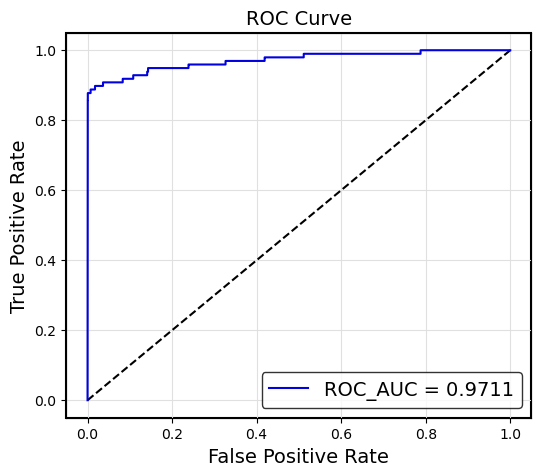

In [43]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

f, ax = plt.subplots(figsize=(6,5))

ax.plot([0, 1], [0, 1], 'k--')
ax.plot(fpr, tpr, color="#0101DF", label=f'ROC_AUC = {roc_auc:.4f}')

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve', fontsize=14)

ax.patch.set_facecolor('white')
ax.grid(True, color='#E0E0E0')
ax.patch.set_edgecolor('black')
ax.patch.set_linewidth(1.5)

ax.legend(loc="lower right", prop={'size': 14}, facecolor='white', edgecolor='black')

plt.show()

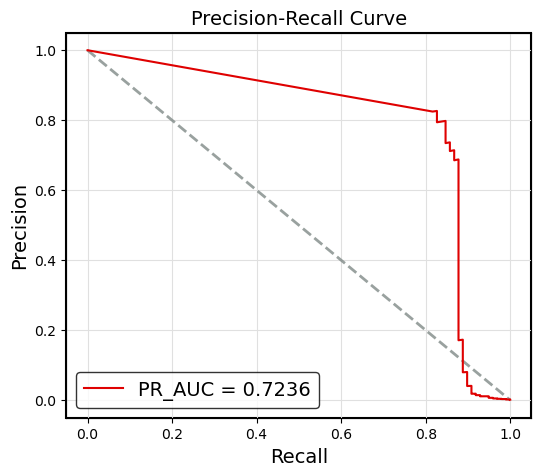

In [44]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

f, ax = plt.subplots(figsize=(6,5))

plt.plot([0, 1], [1, 0], linestyle='--', lw=2, color='#808A87', alpha=0.8)
plt.plot(recall, precision, color="#DF0101", label=f'PR_AUC = {pr_auc:.4f}')

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curve', fontsize=14)

ax.patch.set_facecolor('white')
ax.grid(True, color='#E0E0E0')
ax.patch.set_edgecolor('black')
ax.patch.set_linewidth(1.5)

ax.legend(loc="lower left", prop={'size': 14}, facecolor='white', edgecolor='black')

plt.show()